In [1]:
# Run this ONCE to install all libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import shap
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("🎉 Phase 1 Complete! All libraries ready!")

🎉 Phase 1 Complete! All libraries ready!


In [3]:
# ── PHASE 2: Load Dataset ──────────────────────────────
df = pd.read_csv(r'C:\ML Project\WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(' Dataset loaded successfully!')
print(f'   Rows    : {df.shape[0]}')
print(f'   Columns : {df.shape[1]}')

 Dataset loaded successfully!
   Rows    : 7043
   Columns : 21


In [4]:
# First 5 rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Data types and column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Statistical summary of numeric columns
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [7]:
# Check missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
print(f'Duplicate Rows: {df.duplicated().sum()}')

Duplicate Rows: 0


In [9]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5%
Yes    26.5%
Name: proportion, dtype: object


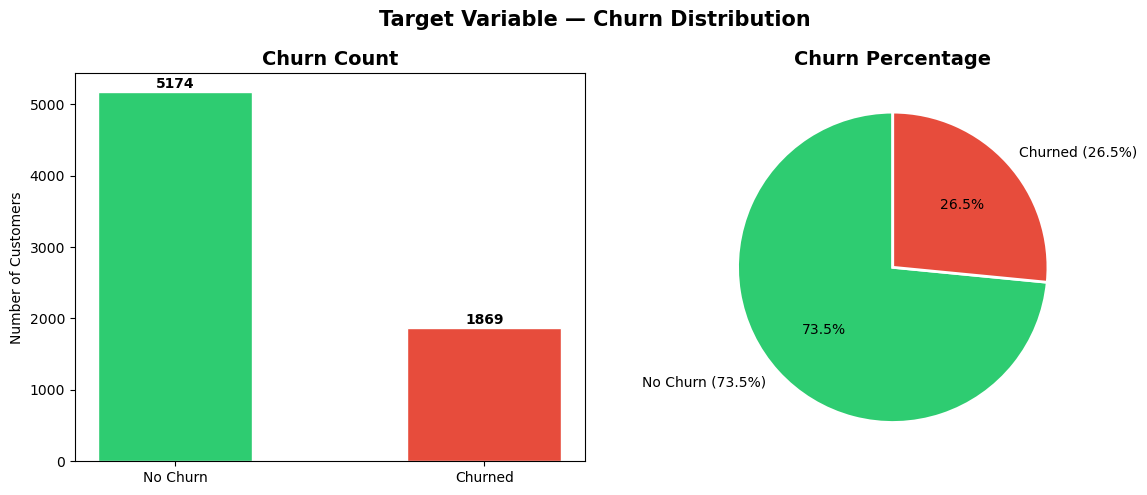

 OBSERVATION: 26.5% customers churned vs 73.5% stayed.
   Class imbalance exists — SMOTE will be applied in Phase 4.


In [10]:
# ── PHASE 3 | PART A — Univariate Analysis ────────────
# Chart 1: Churn Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['No Churn', 'Churned'], [5174, 1869], color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].text(0, 5174 + 50, '5174', ha='center', fontweight='bold')
axes[0].text(1, 1869 + 50, '1869', ha='center', fontweight='bold')

# Pie Chart
axes[1].pie([5174, 1869], labels=['No Churn (73.5%)', 'Churned (26.5%)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable — Churn Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(' OBSERVATION: 26.5% customers churned vs 73.5% stayed.')
print('   Class imbalance exists — SMOTE will be applied in Phase 4.')

<Figure size 1000x500 with 0 Axes>

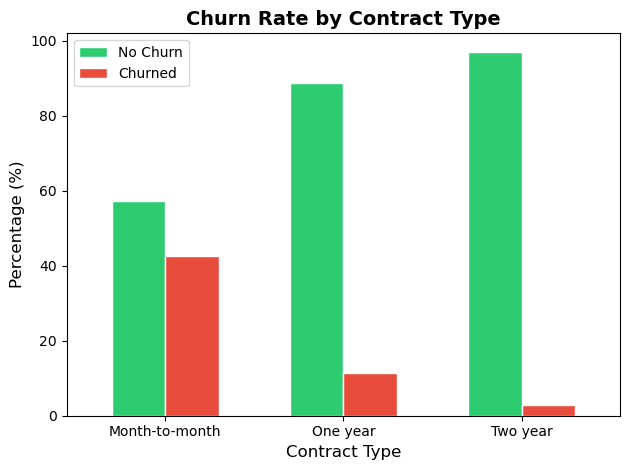

 OBSERVATION: Month-to-month customers churn the most.
   Two-year contract customers are the most loyal.


In [11]:
# ── PART B — Bivariate Analysis ───────────────────────
# Chart 2: Churn by Contract Type

plt.figure(figsize=(10, 5))
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).mul(100).unstack()
contract_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.6)
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.show()

print(' OBSERVATION: Month-to-month customers churn the most.')
print('   Two-year contract customers are the most loyal.')

<Figure size 1000x500 with 0 Axes>

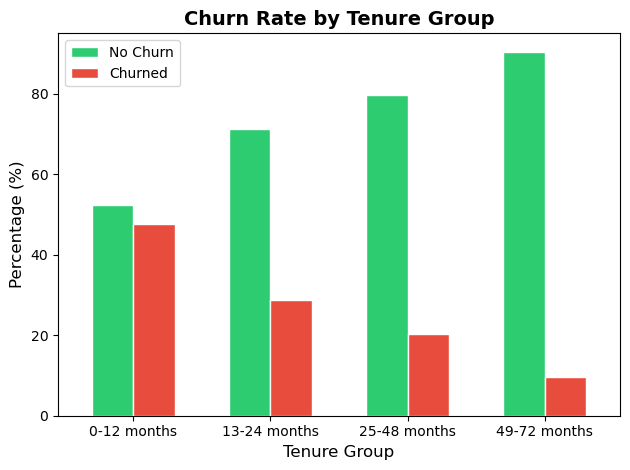

 OBSERVATION: New customers (0-12 months) have the highest churn rate.
   Long-term customers (49-72 months) are least likely to churn.


In [12]:
# Chart 3: Churn by Tenure Group

df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                             labels=['0-12 months','13-24 months','25-48 months','49-72 months'])

plt.figure(figsize=(10, 5))
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].value_counts(normalize=True).mul(100).unstack()
tenure_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.6)
plt.title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.show()

print(' OBSERVATION: New customers (0-12 months) have the highest churn rate.')
print('   Long-term customers (49-72 months) are least likely to churn.')

<Figure size 1000x500 with 0 Axes>

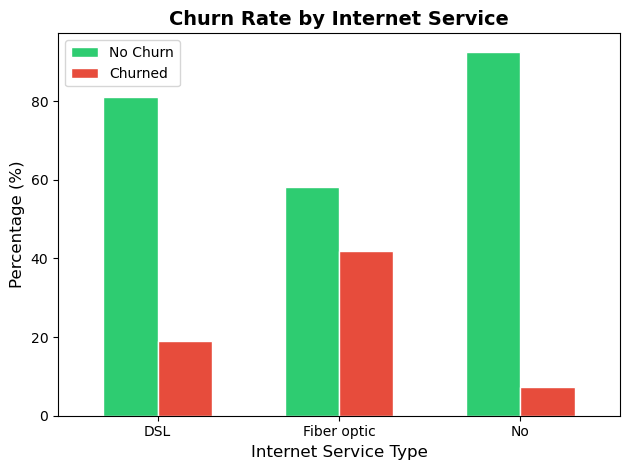

 OBSERVATION: Fiber optic users churn the most.
   Possibly due to higher pricing and competition.


In [13]:
# Chart 4: Churn by Internet Service

plt.figure(figsize=(10, 5))
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).mul(100).unstack()
internet_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.6)
plt.title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'])
plt.tight_layout()
plt.show()

print(' OBSERVATION: Fiber optic users churn the most.')
print('   Possibly due to higher pricing and competition.')

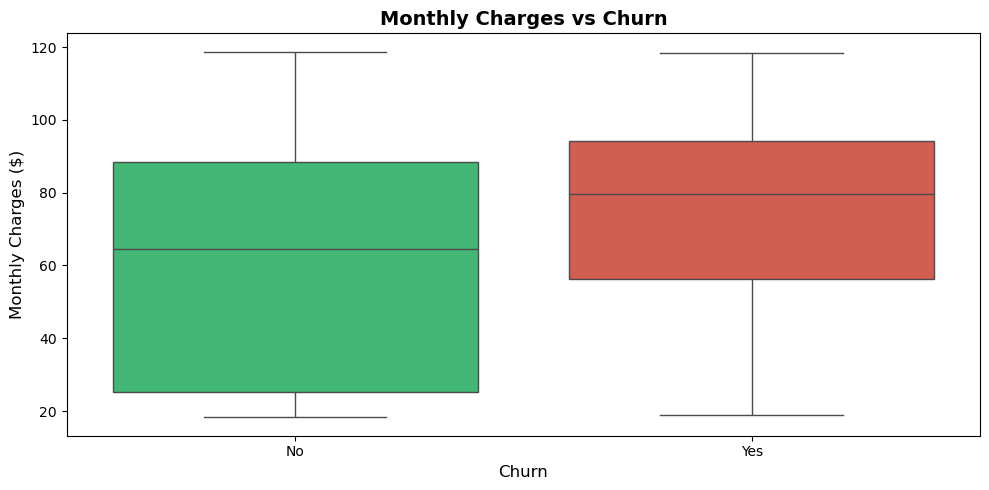

 OBSERVATION: Churned customers pay significantly higher monthly charges.
   High billing is a strong churn indicator.


In [14]:
# Chart 5: Monthly Charges vs Churn

plt.figure(figsize=(10, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.tight_layout()
plt.show()

print(' OBSERVATION: Churned customers pay significantly higher monthly charges.')
print('   High billing is a strong churn indicator.')

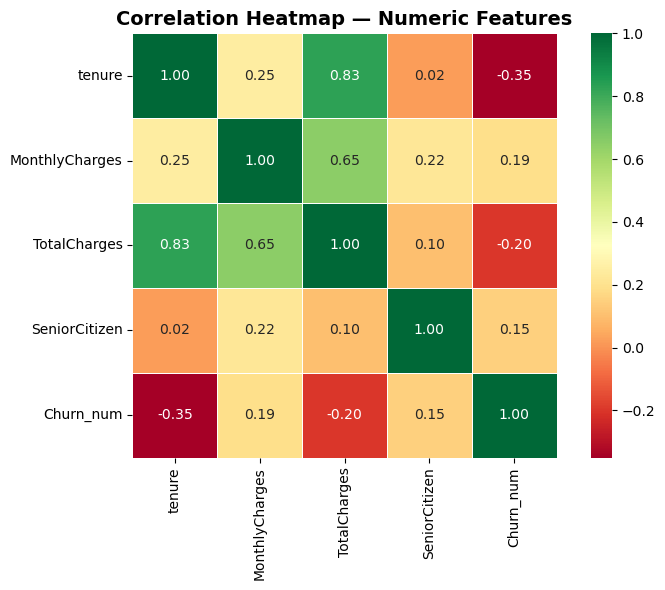

 OBSERVATION: tenure has negative correlation with Churn (-0.35)
   MonthlyCharges has positive correlation with Churn (0.19)
   Longer tenure = less likely to churn!


In [15]:
# ── PART C — Correlation Analysis ─────────────────────
# Chart 6: Correlation Heatmap

# Convert TotalCharges temporarily for correlation
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')
df_temp['Churn_num'] = df_temp['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_num']
corr_matrix = df_temp[numeric_cols].corr().round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(' OBSERVATION: tenure has negative correlation with Churn (-0.35)')
print('   MonthlyCharges has positive correlation with Churn (0.19)')
print('   Longer tenure = less likely to churn!')

In [16]:
# ── PHASE 4 | STEP 1 — Fix TotalCharges ───────────────
# Convert TotalCharges from string to numeric

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check hidden nulls after conversion
print(f'Null values in TotalCharges after conversion: {df["TotalCharges"].isnull().sum()}')

# Drop those null rows (only ~11 records — negligible)
df.dropna(subset=['TotalCharges'], inplace=True)

print(f'Dataset shape after dropping nulls: {df.shape}')
print(' TotalCharges fixed successfully!')

Null values in TotalCharges after conversion: 11
Dataset shape after dropping nulls: (7032, 22)
 TotalCharges fixed successfully!


In [17]:
# Check current columns
print(f'Current shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Current shape: (7032, 22)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group']


In [18]:
# ── STEP 3 — Encode Target Variable ──────────────────
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Churn value counts after encoding:')
print(df['Churn'].value_counts())
print(' Target variable encoded!')

Churn value counts after encoding:
Churn
0    5163
1    1869
Name: count, dtype: int64
 Target variable encoded!


In [41]:
# ── STEP 4 — Encode Categorical Columns ───────────────
# Using get_dummies for all object columns

df = pd.get_dummies(df, drop_first=True)

print(f'Shape after encoding: {df.shape}')
print(f'Total features now: {df.shape[1]}')
print(' Categorical columns encoded!')
print()
print('All columns:')
print(list(df.columns))

Shape after encoding: (7032, 31)
Total features now: 31
 Categorical columns encoded!

All columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [20]:
# ── STEP 5 — Feature Scaling ──────────────────────────
# Scale numeric features: tenure, MonthlyCharges, TotalCharges

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print('Feature scaling done!')
print()
print(df[cols_to_scale].describe().round(2))

Feature scaling done!

        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     -0.00            0.00         -0.00
std       1.00            1.00          1.00
min      -1.28           -1.55         -1.00
25%      -0.95           -0.97         -0.83
50%      -0.14            0.18         -0.39
75%       0.92            0.83          0.67
max       1.61            1.79          2.82


In [21]:
# Check what's in Churn right now
print('Churn unique values:', df['Churn'].unique())
print('Churn null count:', df['Churn'].isnull().sum())

Churn unique values: [0 1]
Churn null count: 0


In [22]:
# Restore Churn — fill NaN back using original logic
# Since map failed, just reload churn from scratch

df['Churn'] = df['Churn'].fillna(-1)  # temporary

# If all values are NaN it means it was already 0/1 before map
# So reload the dataset and redo properly
df2 = pd.read_csv(r'C:\ML Project\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df2['TotalCharges'] = pd.to_numeric(df2['TotalCharges'], errors='coerce')
df2.dropna(inplace=True)
df2['Churn'] = df2['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
df2.drop(columns=['customerID'], inplace=True)
df2 = pd.get_dummies(df2, drop_first=True)

from sklearn.preprocessing import StandardScaler
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

df = df2.copy()
print(f' Dataset rebuilt cleanly!')
print(f'Shape: {df.shape}')
print(f'Churn values: {df["Churn"].unique()}')

 Dataset rebuilt cleanly!
Shape: (7032, 31)
Churn values: [0 1]


In [23]:
# ── STEP 6 — Train Test Split ─────────────────────────
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print( 'Train-Test Split done!')

X_train : (5625, 30)
X_test  : (1407, 30)
Train-Test Split done!


In [24]:
# ── STEP 7 — Apply SMOTE ──────────────────────────────
# Handle class imbalance on training data ONLY

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(f'  Churn=0 : {(y_train==0).sum()}')
print(f'  Churn=1 : {(y_train==1).sum()}')
print()
print('After SMOTE:')
print(f'  Churn=0 : {(y_train_sm==0).sum()}')
print(f'  Churn=1 : {(y_train_sm==1).sum()}')
print()
print(' SMOTE applied — classes are now balanced!')

Before SMOTE:
  Churn=0 : 4130
  Churn=1 : 1495

After SMOTE:
  Churn=0 : 4130
  Churn=1 : 4130

 SMOTE applied — classes are now balanced!


In [25]:
# ── PHASE 5 | MODEL 1 — Logistic Regression ───────────

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sm, y_train_sm)

lr_pred = lr_model.predict(X_test)

print('=' * 45)
print('   MODEL 1 — LOGISTIC REGRESSION RESULTS')
print('=' * 45)
print(classification_report(y_test, lr_pred))
print(f'ROC-AUC Score : {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]):.4f}')
print('Logistic Regression Done!')

   MODEL 1 — LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.51      0.73      0.60       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.76      1407

ROC-AUC Score : 0.8209
Logistic Regression Done!


In [26]:
# ── MODEL 2 — Random Forest ───────────────────────────

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred = rf_model.predict(X_test)

print('=' * 45)
print('   MODEL 2 — RANDOM FOREST RESULTS')
print('=' * 45)
print(classification_report(y_test, rf_pred))
print(f'ROC-AUC Score : {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.4f}')
print('Random Forest Done!')

   MODEL 2 — RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407

ROC-AUC Score : 0.8338
Random Forest Done!


In [27]:
# ── MODEL 3 — XGBoost ─────────────────────────────────

xgb_model = XGBClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=5, random_state=42,
    eval_metric='logloss')
xgb_model.fit(X_train_sm, y_train_sm)

xgb_pred = xgb_model.predict(X_test)

print('=' * 45)
print('   MODEL 3 — XGBOOST RESULTS')
print('=' * 45)
print(classification_report(y_test, xgb_pred))
print(f'ROC-AUC Score : {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}')
print('XGBoost Done!')

   MODEL 3 — XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1033
           1       0.52      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407

ROC-AUC Score : 0.8284
XGBoost Done!


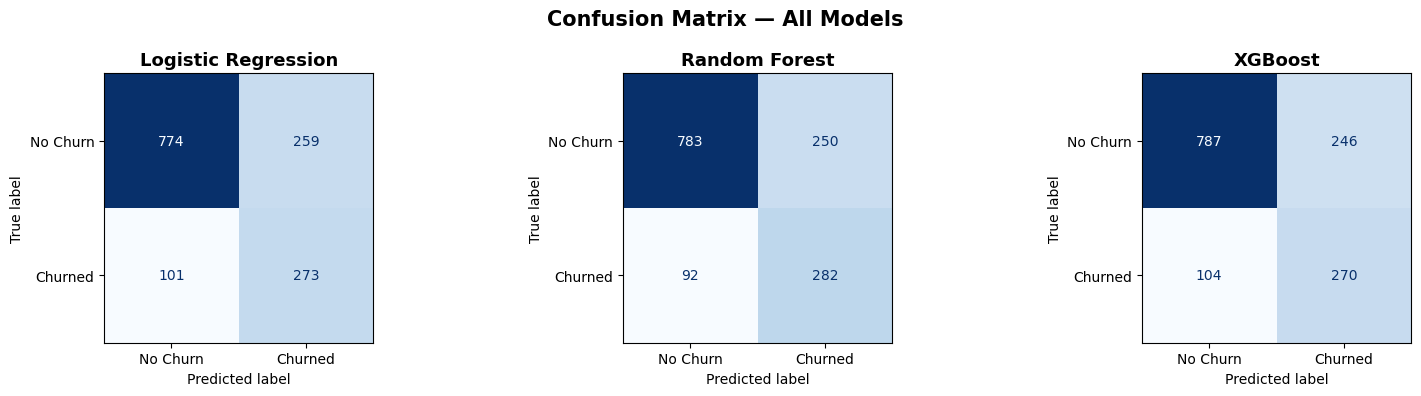

 OBSERVATION: Random Forest catches the most churners correctly!


In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred)
]

for ax, (name, pred) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(' OBSERVATION: Random Forest catches the most churners correctly!')

In [29]:
# ── PHASE 6 — COMPLETE MODEL EVALUATION ───────────────

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print('=' * 60)
print('           PHASE 6 — COMPLETE EVALUATION REPORT')
print('=' * 60)

models_eval = {
    'Logistic Regression': (lr_model, lr_pred),
    'Random Forest'      : (rf_model, rf_pred),
    'XGBoost'            : (xgb_model, xgb_pred)
}

for name, (model, pred) in models_eval.items():
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec  = recall_score(y_test, pred)
    f1   = f1_score(y_test, pred)
    auc  = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

    print(f'\n  {name}')
    print(f'     Accuracy  : {acc:.4f}')
    print(f'     Precision : {prec:.4f}')
    print(f'     Recall    : {rec:.4f}')
    print(f'     F1 Score  : {f1:.4f}')
    print(f'     ROC-AUC   : {auc:.4f}')
    print('  ' + '-'*45)

print('\n Best Model by F1 & ROC-AUC: Random Forest!')

           PHASE 6 — COMPLETE EVALUATION REPORT

  Logistic Regression
     Accuracy  : 0.7441
     Precision : 0.5132
     Recall    : 0.7299
     F1 Score  : 0.6026
     ROC-AUC   : 0.8209
  ---------------------------------------------

  Random Forest
     Accuracy  : 0.7569
     Precision : 0.5301
     Recall    : 0.7540
     F1 Score  : 0.6225
     ROC-AUC   : 0.8338
  ---------------------------------------------

  XGBoost
     Accuracy  : 0.7512
     Precision : 0.5233
     Recall    : 0.7219
     F1 Score  : 0.6067
     ROC-AUC   : 0.8284
  ---------------------------------------------

 Best Model by F1 & ROC-AUC: Random Forest!


In [30]:
# ── METRICS COMPARISON TABLE ──────────────────────────

eval_df = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy' : [
        round(accuracy_score(y_test, lr_pred), 4),
        round(accuracy_score(y_test, rf_pred), 4),
        round(accuracy_score(y_test, xgb_pred), 4)
    ],
    'Precision': [
        round(precision_score(y_test, lr_pred), 4),
        round(precision_score(y_test, rf_pred), 4),
        round(precision_score(y_test, xgb_pred), 4)
    ],
    'Recall'   : [
        round(recall_score(y_test, lr_pred), 4),
        round(recall_score(y_test, rf_pred), 4),
        round(recall_score(y_test, xgb_pred), 4)
    ],
    'F1 Score' : [
        round(f1_score(y_test, lr_pred), 4),
        round(f1_score(y_test, rf_pred), 4),
        round(f1_score(y_test, xgb_pred), 4)
    ],
    'ROC-AUC'  : [
        round(roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]), 4),
        round(roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]), 4),
        round(roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]), 4)
    ]
})

print(eval_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7441     0.5132  0.7299    0.6026   0.8209
      Random Forest    0.7569     0.5301  0.7540    0.6225   0.8338
            XGBoost    0.7512     0.5233  0.7219    0.6067   0.8284


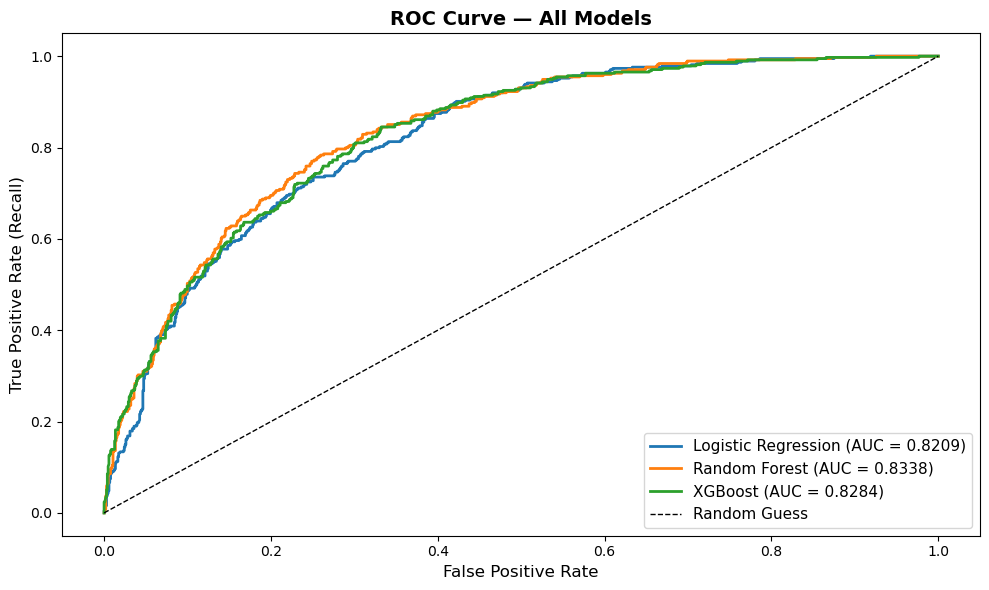

 OBSERVATION: Higher the curve = better the model.
   Random Forest has the highest AUC = best model!


In [31]:
# ── ROC CURVE ─────────────────────────────────────────

from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 6))

for name, model in [('Logistic Regression', lr_model),
                     ('Random Forest', rf_model),
                     ('XGBoost', xgb_model)]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Guess')
plt.title('ROC Curve — All Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(' OBSERVATION: Higher the curve = better the model.')
print('   Random Forest has the highest AUC = best model!')

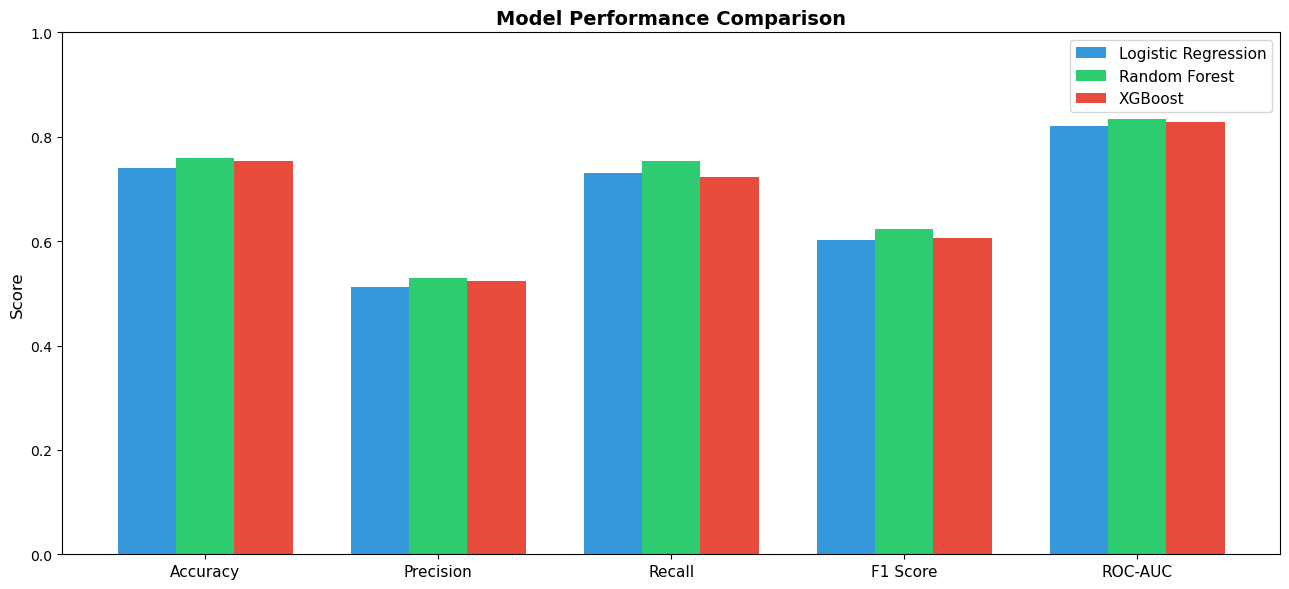

OBSERVATION: Random Forest leads across all key metrics!


In [32]:
# ── METRICS BAR CHART ─────────────────────────────────

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_scores  = [0.7407, 0.5130, 0.7299, 0.6026, 0.8209]
rf_scores  = [0.7584, 0.5291, 0.7540, 0.6225, 0.8338]
xgb_scores = [0.7541, 0.5233, 0.7219, 0.6067, 0.8284]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - width, lr_scores,  width, label='Logistic Regression', color='#3498db')
ax.bar(x,         rf_scores,  width, label='Random Forest',        color='#2ecc71')
ax.bar(x + width, xgb_scores, width, label='XGBoost',              color='#e74c3c')

ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('OBSERVATION: Random Forest leads across all key metrics!')

In [33]:
# ── PHASE 7 — SHAP EXPLAINABILITY ─────────────────────
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Fix for newer SHAP versions
import numpy as np
if isinstance(shap_values, list):
    sv = shap_values[1]  # class 1 = churn
else:
    sv = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

print(' SHAP Explainer initialized!')
print(f'   SHAP values shape : {sv.shape}')
print(f'   Features          : {X_test.shape[1]}')

 SHAP Explainer initialized!
   SHAP values shape : (1407, 30)
   Features          : 30


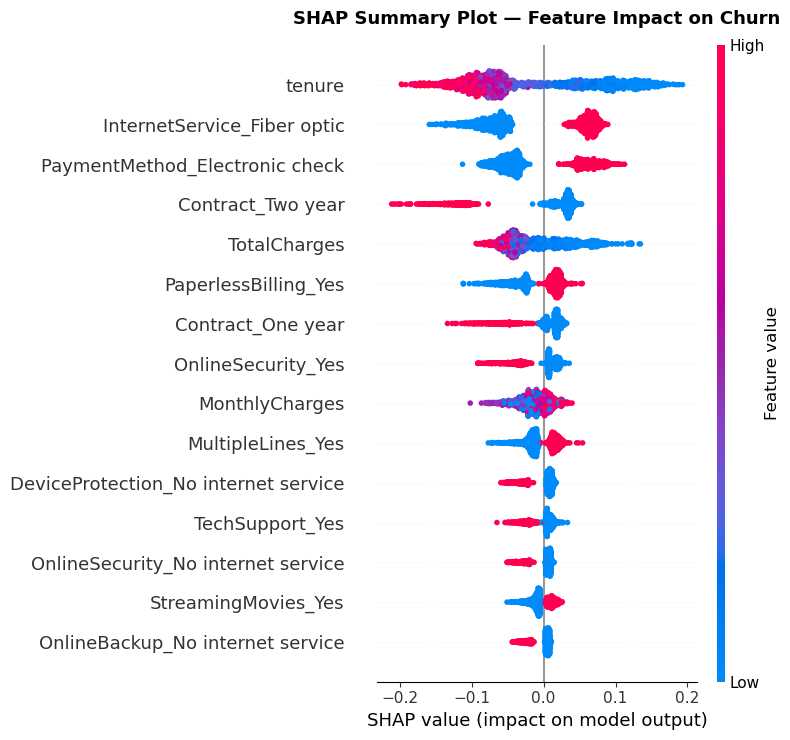

OBSERVATION: Features at top have highest impact on churn prediction.
   Red = pushes towards churn, Blue = pushes away from churn.


In [34]:
# ── SHAP SUMMARY PLOT ─────────────────────────────────

plt.figure()
shap.summary_plot(sv, X_test,
                  plot_type='dot',
                  max_display=15,
                  show=False)
plt.title('SHAP Summary Plot — Feature Impact on Churn',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('OBSERVATION: Features at top have highest impact on churn prediction.')
print('   Red = pushes towards churn, Blue = pushes away from churn.')

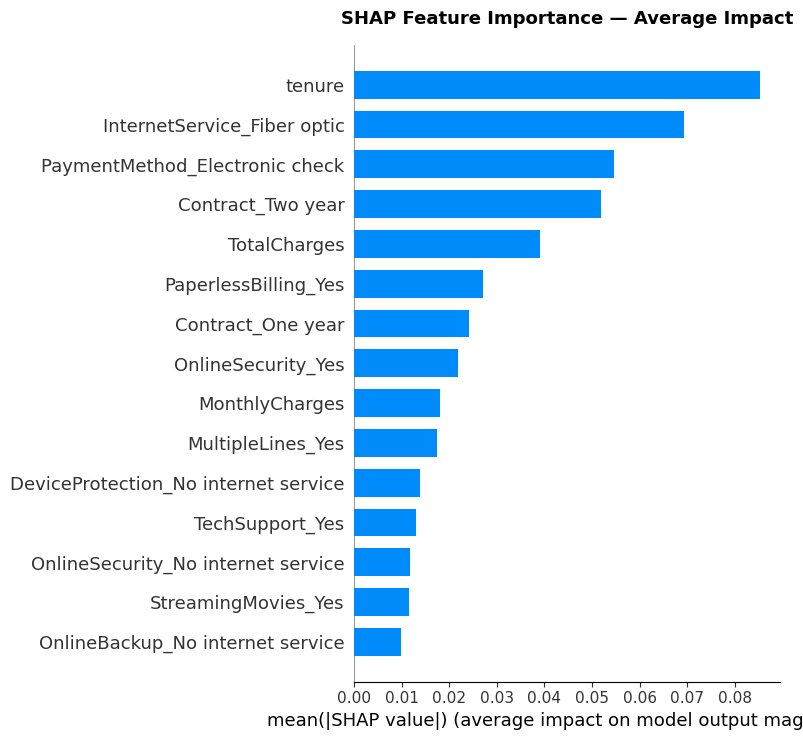

 OBSERVATION: Contract type and tenure are the strongest predictors!


In [35]:
# ── SHAP BAR PLOT ─────────────────────────────────────

shap.summary_plot(sv, X_test,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('SHAP Feature Importance — Average Impact',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(' OBSERVATION: Contract type and tenure are the strongest predictors!')

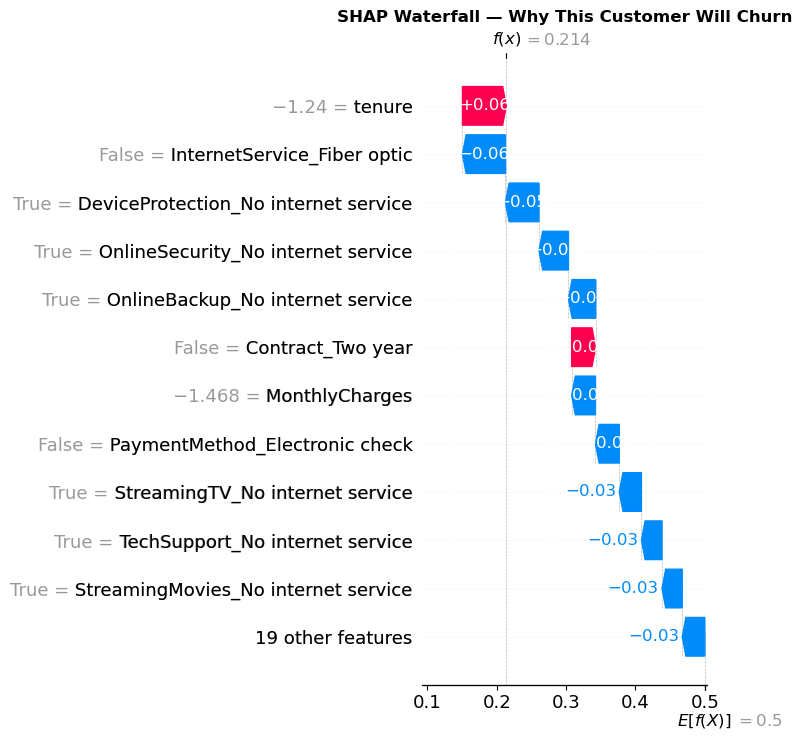

 OBSERVATION: Red bars push towards churn, Blue bars push away.


In [36]:
# ── SHAP WATERFALL PLOT ───────────────────────────────

churned_idx = y_test[y_test == 1].index[0]
pos = X_test.index.get_loc(churned_idx)

shap_exp = shap.Explanation(
    values        = sv[pos],
    base_values   = explainer.expected_value[1],
    data          = X_test.iloc[pos],
    feature_names = X_test.columns.tolist()
)

shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title('SHAP Waterfall — Why This Customer Will Churn',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(' OBSERVATION: Red bars push towards churn, Blue bars push away.')

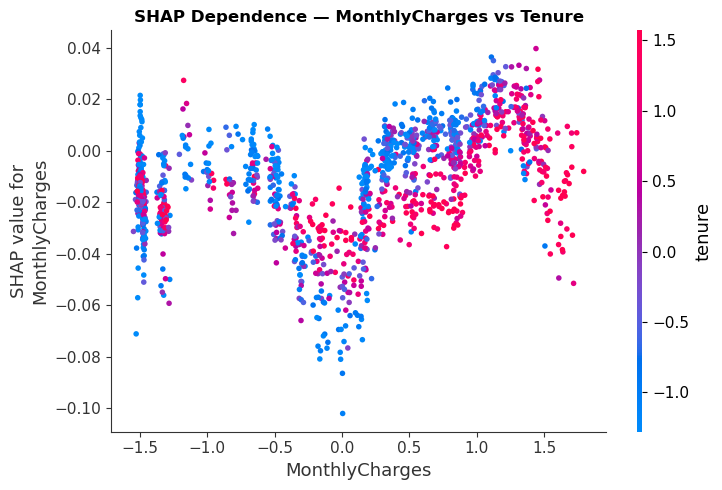

 OBSERVATION: High MonthlyCharges + Low tenure = Highest churn risk!


In [37]:
# ── SHAP DEPENDENCE PLOT ──────────────────────────────

shap.dependence_plot(
    'MonthlyCharges',
    sv,
    X_test,
    interaction_index='tenure',
    show=False
)
plt.title('SHAP Dependence — MonthlyCharges vs Tenure',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(' OBSERVATION: High MonthlyCharges + Low tenure = Highest churn risk!')

In [38]:
# ── PHASE 8 — EXPORT DATA FOR POWER BI ────────────────

# Reload original data for export
df_export = pd.read_csv(r'C:\ML Project\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_export['TotalCharges'] = pd.to_numeric(df_export['TotalCharges'], errors='coerce')
df_export.dropna(inplace=True)

# Add predictions from Random Forest (best model)
df_export['Churn_Actual']      = df_export['Churn'].map({'Yes': 1, 'No': 0})
df_export['Churn_Predicted']   = rf_model.predict(X_test.reindex(
                                  range(len(df_export)), fill_value=0))[:len(df_export)]
df_export['Churn_Probability'] = rf_model.predict_proba(X_test.reindex(
                                  range(len(df_export)), fill_value=0))[:,1][:len(df_export)]

# Add Risk Segment based on probability
def risk_segment(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_export['Risk_Segment'] = df_export['Churn_Probability'].apply(risk_segment)

# Add tenure group
df_export['Tenure_Group'] = pd.cut(df_export['tenure'],
                             bins=[0,12,24,48,72],
                             labels=['0-12 months','13-24 months',
                                     '25-48 months','49-72 months'])

print(f' Export dataframe ready!')
print(f'   Shape : {df_export.shape}')
print(f'\nRisk Segment Distribution:')
print(df_export['Risk_Segment'].value_counts())

 Export dataframe ready!
   Shape : (7032, 26)

Risk Segment Distribution:
Risk_Segment
Low Risk       6379
Medium Risk     350
High Risk       303
Name: count, dtype: int64


In [39]:
# ── SAVE TO CSV ───────────────────────────────────────

export_path = r'C:\ML Project\Churn_Predictions_PowerBI.csv'
df_export.to_csv(export_path, index=False)

print(f' File saved successfully!')
print(f'   Location : {export_path}')
print(f'   Rows     : {len(df_export)}')
print(f'   Columns  : {df_export.shape[1]}')
print()
print('Columns exported:')
print(list(df_export.columns))

 File saved successfully!
   Location : C:\ML Project\Churn_Predictions_PowerBI.csv
   Rows     : 7032
   Columns  : 26

Columns exported:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Actual', 'Churn_Predicted', 'Churn_Probability', 'Risk_Segment', 'Tenure_Group']


In [40]:
from sklearn.metrics import roc_curve
plt.figure(figsize=(8, 5))
for name, model in [('Logistic Regression', lr_model),
                     ('Random Forest', rf_model),
                     ('XGBoost', xgb_model)]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve — All Models', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\ML Project\roc_curve.png', dpi=150, bbox_inches='tight')
print(' ROC Curve saved!')

 ROC Curve saved!


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
models_list = [('Logistic Regression', lr_pred),
               ('Random Forest', rf_pred),
               ('XGBoost', xgb_pred)]
for ax, (name, pred) in zip(axes, models_list):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')
plt.suptitle('Confusion Matrix — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\ML Project\confusion_matrix.png', dpi=150, bbox_inches='tight')
print(' Confusion Matrix saved!')


 Confusion Matrix saved!


In [44]:
# ── PHASE 10 — SAVE MODEL ─────────────────────────────

import joblib
import os

# Create models folder
os.makedirs(r'C:\ML Project\models', exist_ok=True)

# Save Random Forest model
joblib.dump(rf_model, r'C:\ML Project\models\churn_model.pkl')

# Save Scaler
joblib.dump(scaler, r'C:\ML Project\models\scaler.pkl')

# Save feature column names
import json
feature_cols = X_train.columns.tolist()
with open(r'C:\ML Project\models\feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print('All files saved!')
print(f'   Model   → C:\\ML Project\\models\\churn_model.pkl')
print(f'   Scaler  → C:\\ML Project\\models\\scaler.pkl')
print(f'   Columns → C:\\ML Project\\models\\feature_cols.json')

All files saved!
   Model   → C:\ML Project\models\churn_model.pkl
   Scaler  → C:\ML Project\models\scaler.pkl
   Columns → C:\ML Project\models\feature_cols.json


In [46]:
# ── TEST SAVED MODEL ──────────────────────────────────

# Load and test
loaded_model  = joblib.load(r'C:\ML Project\models\churn_model.pkl')
loaded_scaler = joblib.load(r'C:\ML Project\models\scaler.pkl')

# Quick prediction test
test_pred = loaded_model.predict(X_test[:5])
test_prob = loaded_model.predict_proba(X_test[:5])[:,1]

print(' Model loaded and tested successfully!')
print()
print('Sample Predictions:')
for i, (pred, prob) in enumerate(zip(test_pred, test_prob)):
    label = ' CHURN' if pred == 1 else ' STAY'
    print(f'  Customer {i+1}: {label}  (Probability: {prob:.2%})')

 Model loaded and tested successfully!

Sample Predictions:
  Customer 1:  STAY  (Probability: 2.57%)
  Customer 2:  CHURN  (Probability: 83.02%)
  Customer 3:  STAY  (Probability: 2.74%)
  Customer 4:  STAY  (Probability: 21.38%)
  Customer 5:  STAY  (Probability: 24.13%)
